# Тема 6. Конструирование и отбор признаков

## Дополнительные материалы (самостоятельное чтение)

На занятии не разбираем. Две темы:

1. TF-IDF на настоящих текстах: классификатор спам-сообщений
2. Sequential Feature Selection — жадный отбор признаков «по одному»

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector

RANDOM_STATE = 42

---
## 1. TF-IDF на настоящих текстах: спам-фильтр

На занятии TF-IDF считали на трёх придуманных предложениях. Применим тот же приём к настоящей задаче — классический датасет SMS-сообщений, размеченных как `spam`/`ham` (не спам).

In [2]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "text"]
df["is_spam"] = (df["label"] == "spam").astype(int)

print(f"Доля спама: {df['is_spam'].mean():.1%}")
df.head()

Доля спама: 13.4%


,label,text,is_spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(
    df["text"], df["is_spam"], test_size=0.3, random_state=RANDOM_STATE, stratify=df["is_spam"]
)

tfidf = TfidfVectorizer(max_features=3000, stop_words="english")
X_train_tf = tfidf.fit_transform(X_train)
X_valid_tf = tfidf.transform(X_valid)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_tf, y_train)
round(logreg.score(X_valid_tf, y_valid), 4)

0.9671

**96.7%** accuracy — и это без единого шага «понимания языка», модель даже не знает, что такое слово по смыслу, только частоты. Посмотрим, какие слова модель считает наиболее «спамовыми»:

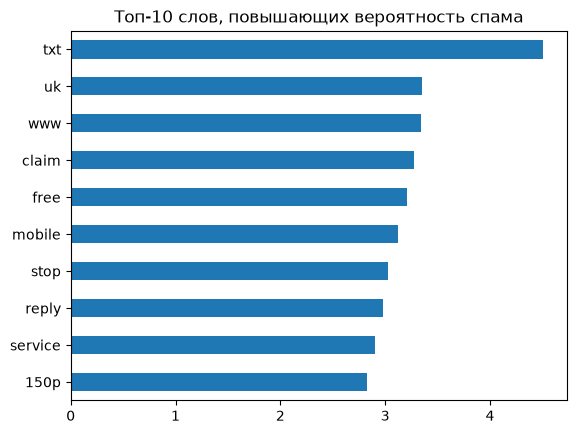

In [4]:
coefs = pd.Series(logreg.coef_[0], index=tfidf.get_feature_names_out())
coefs.sort_values().tail(10).plot(kind="barh", title="Топ-10 слов, повышающих вероятность спама");

`free`, `txt`, `claim`, `won`, `prize` — вполне ожидаемые слова для спам-рассылок. Обратите внимание: `max_features=3000` (взяли только 3000 самых частых слов из словаря — иначе матрица была бы огромной и разреженной) и `stop_words='english'` (выкинули предлоги/местоимения — на английском для них есть готовый список в sklearn, для русского такого готового набора нет, его пришлось бы собирать самим).

---
## 2. Sequential Feature Selection

`SelectKBest` (занятие) оценивает каждый признак **по отдельности**, `SelectFromModel` — по вкладу в одну обученную модель. **Sequential Feature Selection (SFS)** — жаднее: добавляет признаки по одному, каждый раз выбирая тот, что **больше всего** повышает качество модели с уже отобранными признаками (`direction="forward"`; бывает и `"backward"` — начать со всех и убирать по одному).

Дороже по времени (нужно переобучать модель на каждом шаге для каждого кандидата), но учитывает **взаимодействие** между уже отобранными и новыми признаками — то, что `SelectKBest` в принципе не видит.

In [5]:
df_churn = pd.read_csv("../data/telecom_churn.csv")
df_churn["Churn"] = df_churn["Churn"].astype(int)
df_churn["International plan"] = (df_churn["International plan"] == "Yes").astype(int)
df_churn["Voice mail plan"] = (df_churn["Voice mail plan"] == "Yes").astype(int)
X = df_churn.drop(columns=["State", "Churn"])
y = df_churn["Churn"]

sfs = SequentialFeatureSelector(
    RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    n_features_to_select=5, direction="forward", cv=3, n_jobs=-1,
)
sfs.fit(X, y)
X.columns[sfs.get_support()].tolist()

['Area code',
 'Voice mail plan',
 'Total day charge',
 'Total eve minutes',
 'Customer service calls']

В отборе неожиданно оказался `Area code` — скорее всего, ложная находка жадного алгоритма на конкретном разбиении кросс-валидации, а не настоящая закономерность (у `Area code` всего 3 уникальных значения, шанс случайно оказаться полезным на малом числе фолдов не так уж мал). Это иллюстрирует общий риск автоматического отбора признаков: чем агрессивнее и «жаднее» метод, тем выше шанс подобрать признак, который помог на этих конкретных данных случайно. Разумная проверка — смотреть, повторяется ли выбор на разных `random_state`/разбиениях.

---
## Итог

Дальше — `lesson07_unsupervised_theory.ipynb`.